In [9]:
import pandas as pd
df = pd.read_excel('Assignments Data.xlsx')
df.head()

,weight,price
0,2,35
1,4,60
2,5,20
3,3,50
4,6,50


In [10]:
df.shape

(7, 2)

In [11]:
df.describe()

,weight,price
count,7.000000,7.000000
mean,4.571429,47.142857
std,1.718249,14.679107
min,2.000000,20.000000
25%,3.500000,42.500000
50%,5.000000,50.000000
75%,5.500000,57.500000
max,7.000000,60.000000


In [16]:
x = df['weight']
y = df['price']
import numpy as np
mean_x = np.mean(x)
mean_y = np.mean(y)
print(mean_x)
print(mean_y)

4.571428571428571
47.142857142857146


In [17]:
dev_x = x - mean_x
dev_y = y - mean_y
m = np.sum(dev_x*dev_y)/np.sum(dev_x**2)
c = mean_y - m*mean_y
print(m)
print(c)

print(((m*6.5)) + c)

2.620967741935484
-76.41705069124424
-59.380760368663594


In [12]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(df[['weight']],df[['price']])
reg.predict([[6.5]])

C:\Users\Administrator\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[52.19758065]])

Text(0.5, 1.0, 'Vegetable Price')

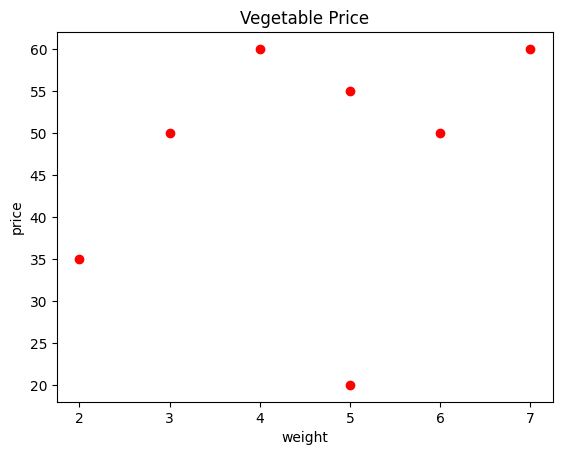

In [15]:
import matplotlib.pyplot as plt
plt.scatter(df.weight,df.price,color='red')
plt.xlabel('weight')
plt.ylabel('price')
plt.title('Vegetable Price')

In [18]:
df2 = df.copy()
df2.head()

,weight,price
0,2,35
1,4,60
2,5,20
3,3,50
4,6,50


In [19]:
df2['Predicted_Price'] = reg.predict(df[['weight']])
df2.head()

,weight,price,Predicted_Price
0,2,35,40.403226
1,4,60,45.645161
2,5,20,48.266129
3,3,50,43.024194
4,6,50,50.887097


In [20]:
df2['res'] = df2['weight'] - df2['Predicted_Price']
df2.head()

,weight,price,Predicted_Price,res
0,2,35,40.403226,-38.403226
1,4,60,45.645161,-41.645161
2,5,20,48.266129,-43.266129
3,3,50,43.024194,-40.024194
4,6,50,50.887097,-44.887097


In [23]:
reg.score(df[['weight']],df[['price']])

0.09412315095348434

In [31]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse = mean_squared_error(df2['Predicted_Price'],df2['weight'])
mae = mean_absolute_error(df2[['Predicted_Price']],df2[['weight']])
print(mse)
print(mae)

1818.9758064516132
42.57142857142857


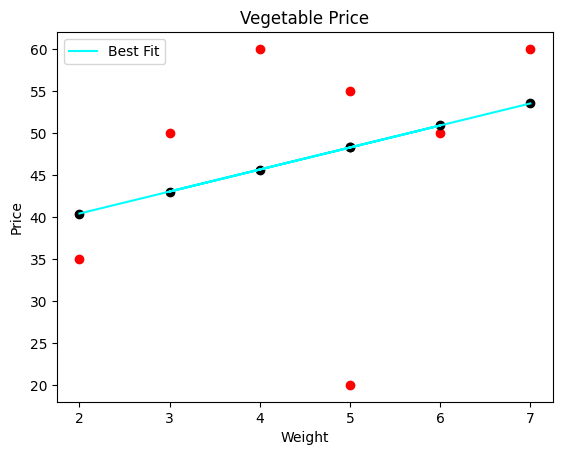

In [33]:
plt.scatter(df.weight,df.price,color='red',marker='o')
plt.plot(df.weight,df2[['Predicted_Price']],label='Best Fit',color='cyan')
plt.scatter(df.weight,df2[['Predicted_Price']],color = 'black')
plt.xlabel("Weight")
plt.ylabel("Price")
plt.title("Vegetable Price")

plt.legend()